In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import ta

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load Dataset
df = pd.read_csv("../data/spy_data.csv")

df.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume,Returns,MA20,MA50,Volatility
0,0,2010-01-04,84.578461,84.623237,83.220190,83.862011,118944600,NaN,NaN,NaN,NaN
1,1,2010-01-05,84.802353,84.839670,84.220238,84.526225,111579900,0.002647,NaN,NaN,NaN
2,2,2010-01-06,84.862068,85.071032,84.653104,84.720269,116074400,0.000704,NaN,NaN,NaN
3,3,2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100,0.004221,NaN,NaN,NaN
4,4,2010-01-08,85.503883,85.541201,84.824751,84.996397,126402800,0.003328,NaN,NaN,NaN


In [15]:
#Basic Data Checks
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  3774 non-null   int64  
 1   Date        3774 non-null   str    
 2   Close       3774 non-null   float64
 3   High        3774 non-null   float64
 4   Low         3774 non-null   float64
 5   Open        3774 non-null   float64
 6   Volume      3774 non-null   int64  
 7   Returns     3773 non-null   float64
 8   MA20        3755 non-null   float64
 9   MA50        3725 non-null   float64
 10  Volatility  3754 non-null   float64
dtypes: float64(8), int64(2), str(1)
memory usage: 324.5 KB


Unnamed: 0     0
Date           0
Close          0
High           0
Low            0
Open           0
Volume         0
Returns        1
MA20          19
MA50          49
Volatility    20
dtype: int64

In [16]:
#Convert Data Column
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df = df.set_index("Date")

df.head()

,Unnamed: 0,Close,High,Low,Open,Volume,Returns,MA20,MA50,Volatility
Date,,,,,,,,,,
2010-01-04,0,84.578461,84.623237,83.220190,83.862011,118944600,NaN,NaN,NaN,NaN
2010-01-05,1,84.802353,84.839670,84.220238,84.526225,111579900,0.002647,NaN,NaN,NaN
2010-01-06,2,84.862068,85.071032,84.653104,84.720269,116074400,0.000704,NaN,NaN,NaN
2010-01-07,3,85.220306,85.324788,84.466539,84.705356,131091100,0.004221,NaN,NaN,NaN
2010-01-08,4,85.503883,85.541201,84.824751,84.996397,126402800,0.003328,NaN,NaN,NaN


In [ ]:
#Create basic price features
#Daily Returns of SPY
df["daily_return"] = df["Close"].pct_change()

#Log Returns of SPY
df["log_return"] = np.log(
    df["Close"] / df["Close"].shift(1)
)

#Price Movement Features
df["price_change"] = df["Close"] - df["Open"]

df["high_low_range"] = df["High"] - df["Low"]

df["close_position"] = (
    (df["Close"] - df["Low"]) /
    (df["High"] - df["Low"])
)

In [19]:
#Moving Average Features
#Simple Moving Average
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

#Exponential Moving Average
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()
df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()

#Moving Average Difference
df["MA_difference"] = (df["EMA_20"] - df["EMA_50"])

In [ ]:
#RSI Indicator
df["RSI"] = ta.momentum.RSIIndicator(
    close=df["Close"],
    window=14
).rsi()

In [21]:
#MACD Features
macd = ta.trend.MACD(
    close=df["Close"]
)

df["MACD"] = macd.macd()

df["MACD_signal"] = macd.macd_signal()

df["MACD_difference"] = macd.macd_diff()

In [22]:
#Bollinger Bands
bollinger = ta.volatility.BollingerBands(
    close=df["Close"],
    window=20,
    window_dev=2
)


df["BB_high"] = (
    bollinger.bollinger_hband()
)

df["BB_low"] = (
    bollinger.bollinger_lband()
)

df["BB_middle"] = (
    bollinger.bollinger_mavg()
)


df["BB_width"] = (
    df["BB_high"] -
    df["BB_low"]
)

In [23]:
#ATR Volatility Indicator
atr = ta.volatility.AverageTrueRange(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14
)


df["ATR"] = atr.average_true_range()

In [24]:
#Volument Features
#Volume Moving Average
df["Volume_SMA_20"] = (
    df["Volume"]
    .rolling(20)
    .mean()
)
#Volume Change
df["volume_change"] = (
    df["Volume"]
    .pct_change()
)

In [25]:
#Lag Features
for lag in [1,2,5]:
    
    df[f"return_lag_{lag}"] = (
        df["daily_return"]
        .shift(lag)
    )

In [ ]:
#Rolling Statistics
#Rolling Mean
df["rolling_mean_10"] = (
    df["Close"]
    .rolling(10)
    .mean()
)


df["rolling_mean_30"] = (
    df["Close"]
    .rolling(30)
    .mean()
)

#Rolling Volatility
df["volatility_10"] = (
    df["daily_return"]
    .rolling(10)
    .std()
)


df["volatility_30"] = (
    df["daily_return"]
    .rolling(30)
    .std()
)

In [27]:
#Momentum Features
for window in [5,10,30]:
    
    df[f"momentum_{window}"] = (
        df["Close"]
        .pct_change(window)
    )

In [28]:
#Calender Features
df["day_of_week"] = (
    df.index.dayofweek
)


df["month"] = (
    df.index.month
)


df["quarter"] = (
    df.index.quarter
)

In [30]:
#Create Prediction Target
#Tomorrow direction
df["future_close"] = (
    df["Close"]
    .shift(-1)
)
df["target"] = (
    df["future_close"] > df["Close"]
).astype(int)
df[["Close","future_close","target"]].head(10)

,Close,future_close,target
Date,,,
2010-01-04,84.578461,84.802353,1
2010-01-05,84.802353,84.862068,1
2010-01-06,84.862068,85.220306,1
2010-01-07,85.220306,85.503883,1
2010-01-08,85.503883,85.623314,1
2010-01-11,85.623314,84.824768,0
2010-01-12,84.824768,85.541191,1
2010-01-13,85.541191,85.772568,1
2010-01-14,85.772568,84.809845,0


In [ ]:
#Remove Temporary Columns
df.drop(
    columns=["future_close"],
    inplace=True
)

In [32]:
#Handle Missing Values
df.isnull().sum()
df.dropna(inplace=True)

In [ ]:
#Check final Dataset
df.shape
df.head()

,Unnamed: 0,Close,High,Low,Open,Volume,Returns,MA20,MA50,Volatility,daily_return,log_return,price_change,high_low_range,close_position,SMA_20,SMA_50,EMA_20,EMA_50,MA_difference,RSI,MACD,MACD_signal,MACD_difference,BB_high,BB_low,BB_middle,BB_width,ATR,Volume_SMA_20,volume_change,return_lag_1,return_lag_2,return_lag_5,rolling_mean_10,rolling_mean_30,momentum_5,momentum_10,momentum_30,day_of_week,month,quarter,target
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-03-16,49,86.877113,86.959201,86.190510,86.429327,168673000,0.007966,84.156820,83.279019,0.005395,0.007966,0.007934,0.447786,0.768691,0.893211,84.156820,83.279019,84.507566,83.740041,0.767524,75.054839,1.096926,0.766978,0.329947,87.227441,81.086199,84.156820,6.141242,0.903095,169983295.0,0.148867,0.000260,0.000087,0.001662,85.503896,82.955024,0.017037,0.037523,0.067394,1,3,1,1
2010-03-17,50,87.392036,87.675635,86.884550,87.138296,177468100,0.005927,84.412056,83.335290,0.005422,0.005927,0.005910,0.253740,0.791085,0.641507,84.412056,83.335290,84.782277,83.883257,0.899020,77.195351,1.185197,0.850622,0.334575,87.662049,81.162062,84.412056,6.499988,0.895625,170414445.0,0.052143,0.007966,0.000260,0.004456,85.862122,83.122196,0.018526,0.042743,0.060881,2,3,1,0
2010-03-18,51,87.347275,87.518921,86.996512,87.399516,196509100,-0.000512,84.640797,83.386189,0.005433,-0.000512,-0.000512,-0.052241,0.522410,0.671433,84.640797,83.386189,85.026563,84.019101,1.007462,76.580179,1.237277,0.927953,0.309324,88.037650,81.243944,84.640797,6.793705,0.868967,170554470.0,0.107293,0.005927,0.007966,0.004175,86.190495,83.301558,0.013773,0.039062,0.065647,3,3,1,0
2010-03-19,52,86.905121,87.894297,86.567898,86.905121,226641100,-0.005062,84.838849,83.427050,0.005704,-0.005062,-0.005075,0.000000,1.326398,0.254239,84.838849,83.427050,85.205473,84.132278,1.073195,70.595586,1.228710,0.988105,0.240606,88.278525,81.399172,84.838849,6.879353,0.901641,170752280.0,0.153336,-0.000512,0.005927,0.000087,86.354500,83.550513,0.008553,0.019235,0.094021,4,3,1,1
2010-03-22,53,87.369728,87.527102,86.358072,86.410528,184477800,0.005346,85.059385,83.470038,0.005718,0.005346,0.005332,0.959200,1.169030,0.865381,85.059385,83.470038,85.411593,84.259237,1.152356,72.984641,1.245058,1.039495,0.205563,88.553830,81.564940,85.059385,6.988890,0.920740,173358825.0,-0.186036,-0.005062,-0.000512,0.000260,86.563472,83.809483,0.013681,0.024504,0.097601,0,3,1,1


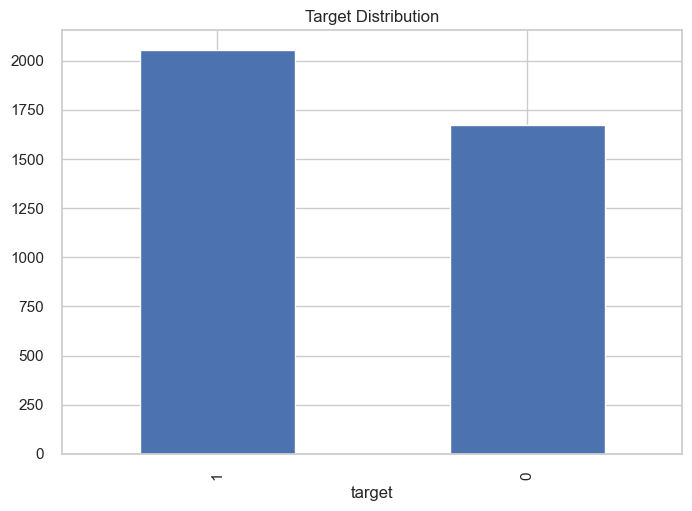

In [34]:
#Check Target Distribution
df["target"].value_counts()

df["target"].value_counts().plot(
    kind="bar",
    title="Target Distribution"
)

plt.show()

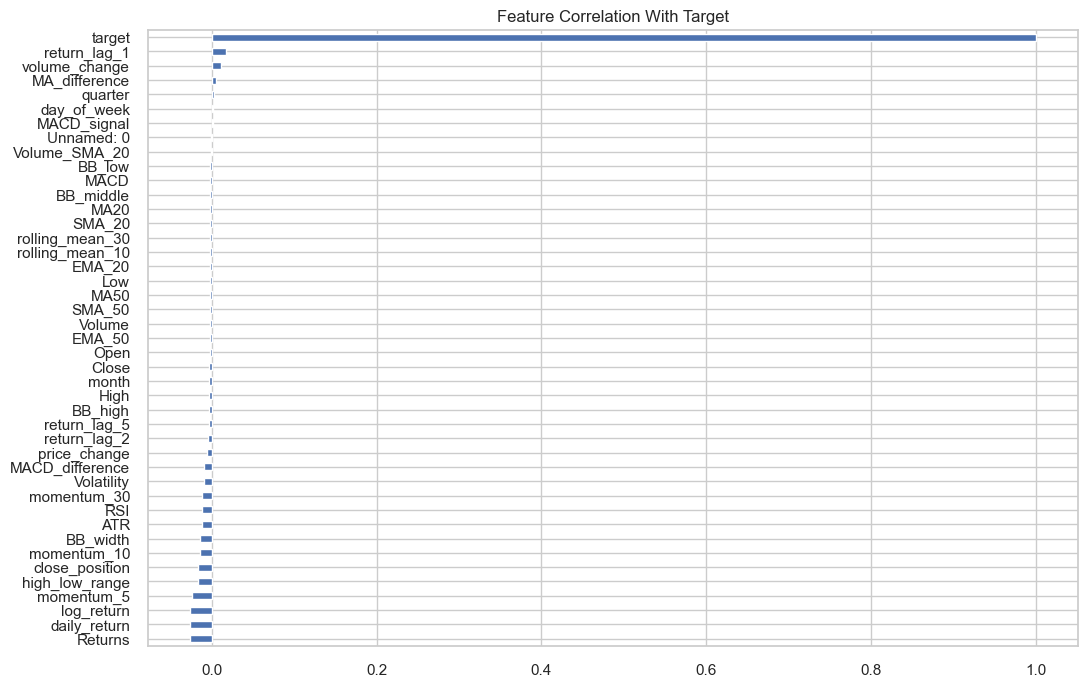

In [35]:
#Feature Correlation
plt.figure(figsize=(12,8))

df.corr()["target"].sort_values().plot(
    kind="barh"
)

plt.title(
    "Feature Correlation With Target"
)

plt.show()

In [36]:
df.to_csv(
    "../data/processed_stock_data.csv"
)

In [37]:
df.columns.tolist()

['Unnamed: 0',
 'Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'Returns',
 'MA20',
 'MA50',
 'Volatility',
 'daily_return',
 'log_return',
 'price_change',
 'high_low_range',
 'close_position',
 'SMA_20',
 'SMA_50',
 'EMA_20',
 'EMA_50',
 'MA_difference',
 'RSI',
 'MACD',
 'MACD_signal',
 'MACD_difference',
 'BB_high',
 'BB_low',
 'BB_middle',
 'BB_width',
 'ATR',
 'Volume_SMA_20',
 'volume_change',
 'return_lag_1',
 'return_lag_2',
 'return_lag_5',
 'rolling_mean_10',
 'rolling_mean_30',
 'momentum_5',
 'momentum_10',
 'momentum_30',
 'day_of_week',
 'month',
 'quarter',
 'target']

In [39]:
df.shape

(3725, 43)